In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Netflix Dataset.csv")

# Kolla datatyper
print(df.dtypes)
print(df.head())

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_D

In [ ]:
# Filmer: Duration innehåller "min"
movies = df[df['Duration'].str.contains("min", na=False)].copy()
shows = df[df['Duration'].str.contains("Season", na=False)].copy()

# Extrahera minuter och säsonger
movies['Minutes'] = movies['Duration'].str.extract(r'(\d+)').astype(float)
shows['Seasons'] = shows['Duration'].str.extract(r'(\d+)').astype(float)

# Rensa Duration-text
movies['Duration'] = movies['Duration'].str.replace(r'\d+', '', regex=True).str.strip()
shows['Duration'] = shows['Duration'].str.replace(r'\d+', '', regex=True).str.strip()

# Fyll missing description
movies['Description'] = movies['Description'].fillna("")
shows['Description'] = shows['Description'].fillna("")

# Extrahera år
movies['Release_Year'] = pd.to_datetime(movies['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)
shows['Release_Year'] = pd.to_datetime(shows['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)


# Kontrollera resultat
print(f"Antal filmer: {movies.shape[0]}")
print(movies[['Title', 'Duration', 'Minutes']].head())

print(f"Antal serier: {shows.shape[0]}")
print(shows[['Title', 'Duration', 'Seasons']].head())


Train: 3227, Val: 1076, Test: 1076
Antal klasser: 15
Klasser: ['G' 'NC-17' 'NR' 'PG' 'PG-13' 'R' 'TV-14' 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y'
 'TV-Y7' 'TV-Y7-FV' 'UR' 'Unknown']


In [ ]:
# Splitta 'Type' till listor
movies['Genres'] = movies['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])
shows['Genres']  = shows['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])

# Multi-hot encoding av genrer
mlb = MultiLabelBinarizer()
genres_movies = mlb.fit_transform(movies['Genres'])
genres_shows  = mlb.transform(shows['Genres'])

# Vanliga kategoriska features (utan 'Type', vi har ersatt den med Genres!)
cat_cols = ['Category', 'Country', 'Rating']
encoder = OneHotEncoder(handle_unknown='ignore')

cat_movies = encoder.fit_transform(movies[cat_cols].fillna('Unknown'))
cat_shows  = encoder.transform(shows[cat_cols].fillna('Unknown'))

# Numeriska features
num_movies = StandardScaler().fit_transform(movies[['Minutes', 'Release_Year']].fillna(0))
num_shows  = StandardScaler().fit_transform(shows[['Seasons', 'Release_Year']].fillna(0))

# Kombinera alla features (beskrivning + kategoriska + genres + numeriska)
X_movies = hstack([tfidf_movies, cat_movies, genres_movies, num_movies])
X_shows  = hstack([tfidf_shows, cat_shows, genres_shows, num_shows])

X_movies = csr_matrix(X_movies)
X_shows  = csr_matrix(X_shows)


c:\Users\SebbePwnYou\anaconda3\envs\Python\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['Anime Series', 'British TV Shows', 'Classic & Cult TV', 'Crime TV Shows', 'Docuseries', 'International TV Shows', "Kids' TV", 'Korean TV Shows', 'Reality TV', 'Romantic TV Shows', 'Science & Nature TV', 'Spanish-Language TV Shows', 'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror', 'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Shows', 'TV Thrillers', 'Teen TV Shows'] will be ignored
  warnings.warn(


In [31]:
# KMeans klustring
kmeans_movies = KMeans(n_clusters=6, random_state=42)
movies['Cluster'] = kmeans_movies.fit_predict(X_movies)

kmeans_shows = KMeans(n_clusters=6, random_state=42)
shows['Cluster'] = kmeans_shows.fit_predict(X_shows)

# Title → index mapping för snabb lookup
title_to_idx_movies = pd.Series(movies.index.values, index=movies['Title']).to_dict()
title_to_idx_shows  = pd.Series(shows.index.values, index=shows['Title']).to_dict()

# Hjälpfunktion: Hitta liknande filmer/serier
def get_similar(title, top_n=5, is_movie=True):
    if is_movie:
        df_ = movies
        X_ = X_movies
        title_to_idx = title_to_idx_movies
    else:
        df_ = shows
        X_ = X_shows
        title_to_idx = title_to_idx_shows
        
    if title not in title_to_idx:
        return [], []
    
    idx = title_to_idx[title]
    pos = df_.index.get_loc(idx)
    cluster_id = df_.loc[idx, 'Cluster']
    
    # Kandidater i samma kluster
    candidates = df_[(df_['Cluster'] == cluster_id) & (df_.index != idx)].index.tolist()
    
    if len(candidates) < top_n:
        # Fyll på med hela datasetet
        candidates = df_[df_.index != idx].index.tolist()
    
    candidate_pos = [df_.index.get_loc(i) for i in candidates]
    sims = cosine_similarity(X_[pos], X_[candidate_pos]).flatten()
    top_idx = np.argsort(sims)[::-1][:top_n]
    similar_idx = [candidates[i] for i in top_idx]
    
    return df_.loc[similar_idx, 'Title'].tolist(), similar_idx


In [32]:
# t-SNE visualisering
def plot_tsne(title, top_n=5, is_movie=True):
    if is_movie:
        df_ = movies
        X_ = X_movies
        title_to_idx = title_to_idx_movies
    else:
        df_ = shows
        X_ = X_shows
        title_to_idx = title_to_idx_shows
    
    titles, sim_idx = get_similar(title, top_n, is_movie)
    if len(titles) == 0:
        print("Inga grannar hittades.")
        return
    
    idx = title_to_idx[title]
    pos = df_.index.get_loc(idx)
    sim_positions = [df_.index.get_loc(i) for i in sim_idx]
    
    # PCA → 50D
    X_50d = PCA(n_components=min(50, X_.shape[1]), random_state=42).fit_transform(X_.toarray())
    
    # t-SNE → 2D
    tsne = TSNE(n_components=2, perplexity=min(30, len(df_)-1), random_state=42)
    X_2d = tsne.fit_transform(X_50d)
    
    plt.figure(figsize=(12,8))
    plt.scatter(X_2d[:,0], X_2d[:,1], c='lightgray', alpha=0.3, label='Alla')
    plt.scatter(X_2d[sim_positions,0], X_2d[sim_positions,1], c='blue', s=120, label='Närmaste grannar', edgecolor='black')
    plt.scatter(X_2d[pos,0], X_2d[pos,1], c='red', s=200, label=title, marker='*', edgecolor='black')
    plt.title(f"t-SNE klustervisualisering för '{title}'")
    plt.legend()
    plt.show()
    
    print(f"\nDe {len(titles)} närmaste titlarna till '{title}':")
    for i, t in enumerate(titles, 1):
        print(f"{i}. {t}")


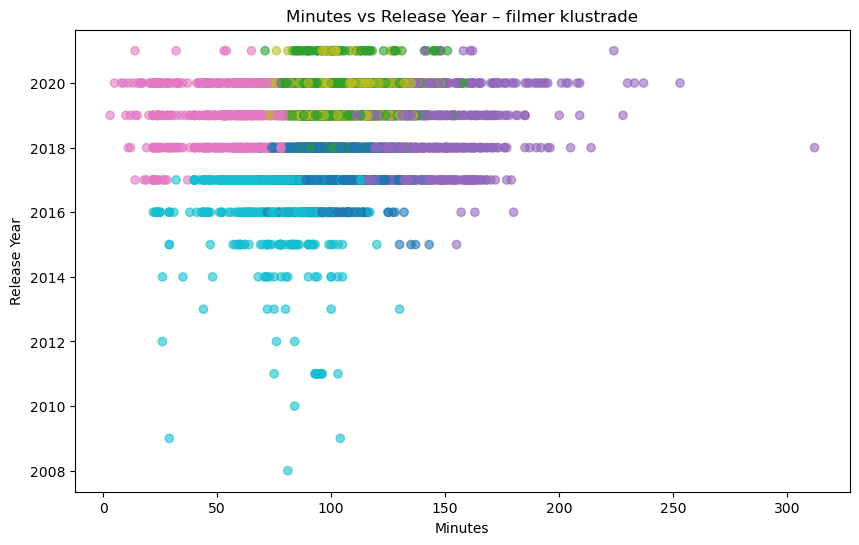

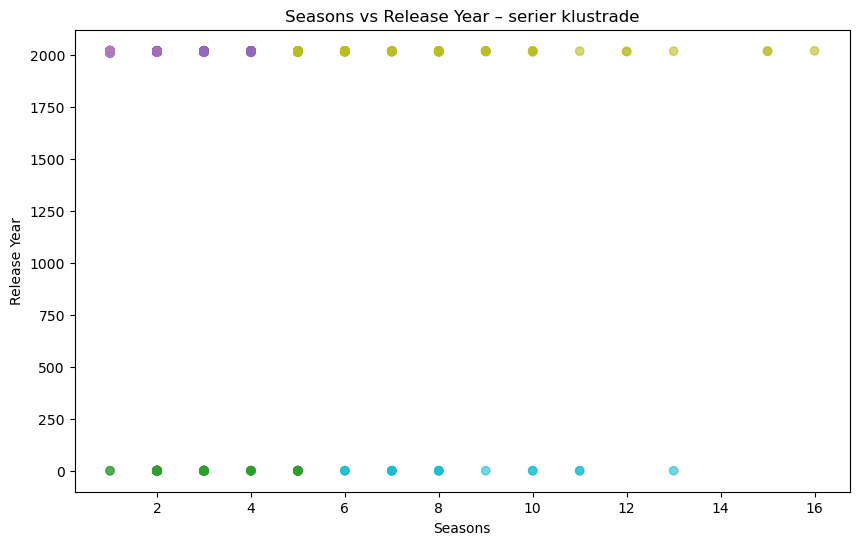

In [33]:
# Exploratory plots
# Minutes vs Release Year
plt.figure(figsize=(10,6))
plt.scatter(movies['Minutes'], movies['Release_Year'], c=movies['Cluster'], cmap='tab10', alpha=0.6)
plt.xlabel("Minutes")
plt.ylabel("Release Year")
plt.title("Minutes vs Release Year – filmer klustrade")
plt.show()

# Se samma för serier
plt.figure(figsize=(10,6))
plt.scatter(shows['Seasons'], shows['Release_Year'], c=shows['Cluster'], cmap='tab10', alpha=0.6)
plt.xlabel("Seasons")
plt.ylabel("Release Year")
plt.title("Seasons vs Release Year – serier klustrade")
plt.show()

In [34]:
for cluster_id, group in movies.groupby("Cluster"):
    all_genres = [genre for sublist in group['Genres'] for genre in sublist]
    genre_counts = Counter(all_genres)
    top_genres = genre_counts.most_common(5)  # topp 5
    print(f"\nCluster {cluster_id}: {len(group)} filmer")
    for genre, count in top_genres:
        print(f"  - {genre}: {count} st")


Cluster 0: 1134 filmer
  - International Movies: 725 st
  - Dramas: 507 st
  - Comedies: 308 st
  - Independent Movies: 225 st
  - Action & Adventure: 180 st

Cluster 1: 1319 filmer
  - Dramas: 467 st
  - Comedies: 459 st
  - Action & Adventure: 248 st
  - Children & Family Movies: 234 st
  - Independent Movies: 219 st

Cluster 2: 761 filmer
  - International Movies: 678 st
  - Dramas: 550 st
  - Comedies: 260 st
  - Action & Adventure: 150 st
  - Romantic Movies: 114 st

Cluster 3: 622 filmer
  - Documentaries: 207 st
  - Stand-Up Comedy: 193 st
  - Children & Family Movies: 145 st
  - International Movies: 69 st
  - Comedies: 54 st

Cluster 4: 969 filmer
  - International Movies: 910 st
  - Dramas: 507 st
  - Comedies: 324 st
  - Romantic Movies: 152 st
  - Independent Movies: 130 st

Cluster 5: 574 filmer
  - Documentaries: 226 st
  - Stand-Up Comedy: 121 st
  - Children & Family Movies: 84 st
  - Comedies: 67 st
  - Dramas: 59 st


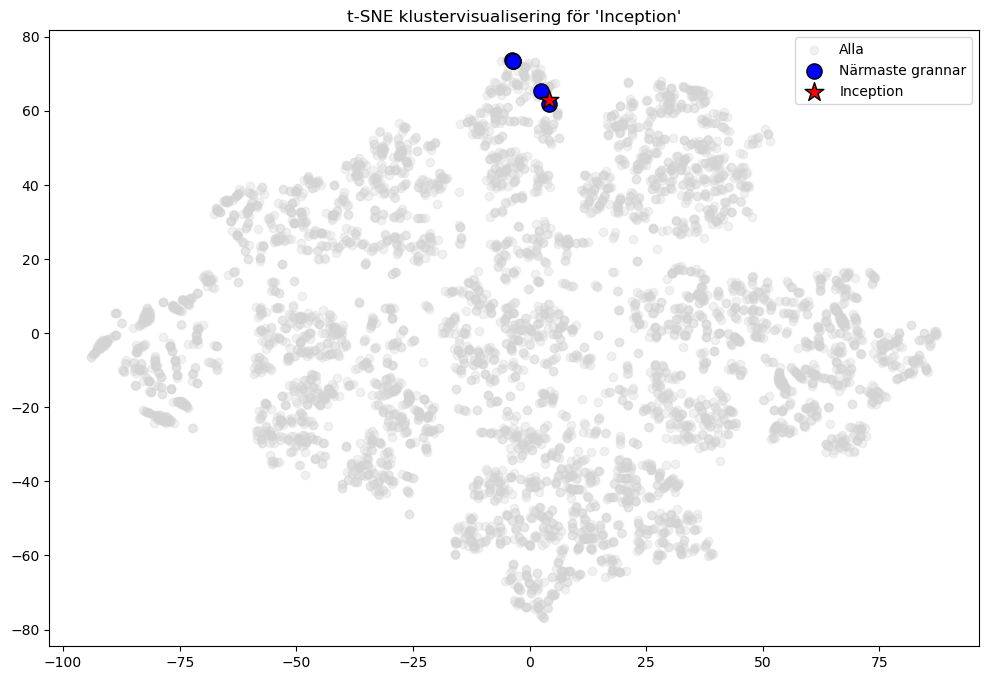


De 5 närmaste titlarna till 'Inception':
1. Superman Returns
2. Spider-Man 3
3. The Da Vinci Code
4. Casino Royale
5. John Carter


In [35]:
plot_tsne("Inception", top_n=5, is_movie=True)

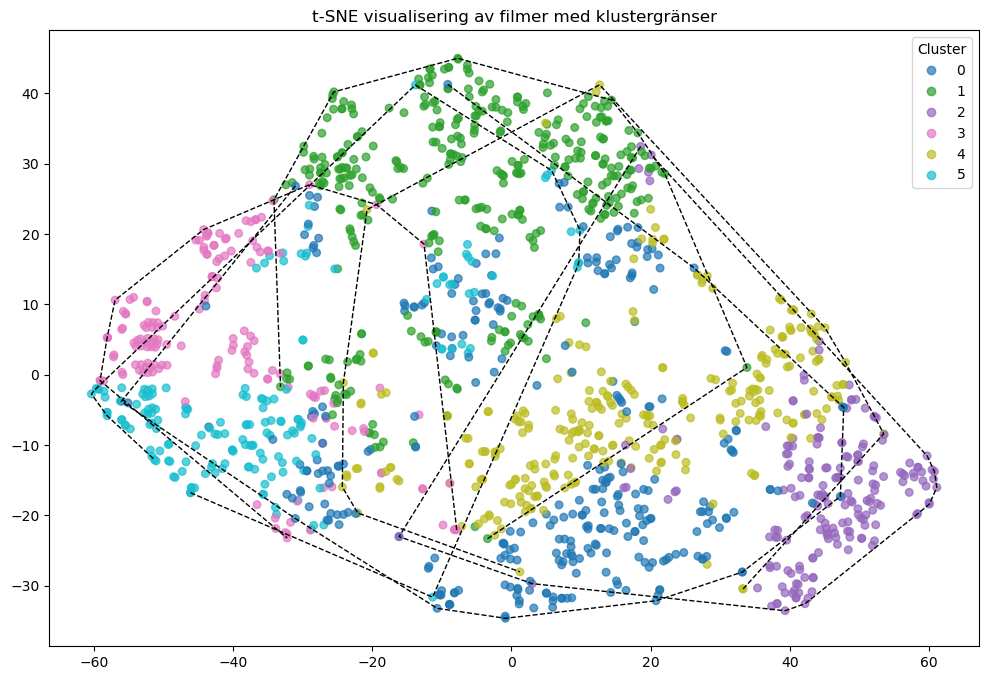

In [36]:
def plot_clusters_with_borders_movies(sample_size=2000):
    # Ta ut sample
    if len(movies) > sample_size:
        sampled_idx = np.random.choice(len(movies), size=sample_size, replace=False)
    else:
        sampled_idx = np.arange(len(movies))

    X_sample = X_movies[sampled_idx].toarray()
    cluster_sample = movies.iloc[sampled_idx]['Cluster'].values

    # PCA → 50D
    X_pca = PCA(n_components=min(50, X_sample.shape[1]), random_state=42).fit_transform(X_sample)

    # t-SNE → 2D
    tsne = TSNE(n_components=2, perplexity=min(30, len(sampled_idx)-1), random_state=42)
    X_2d = tsne.fit_transform(X_pca)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=cluster_sample, cmap="tab10", alpha=0.7, s=30)

    # Rita klustergränser med ConvexHull
    for cluster_id in np.unique(cluster_sample):
        points = X_2d[cluster_sample == cluster_id]
        if len(points) >= 3:
            hull = ConvexHull(points)
            plt.plot(points[hull.vertices,0], points[hull.vertices,1], 'k--', lw=1)

    plt.title("t-SNE visualisering av filmer med klustergränser")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.show()

# Kör den
plot_clusters_with_borders_movies(sample_size=1500)

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_D

[I 2025-09-15 15:07:06,800] A new study created in memory with name: no-name-6783175c-12f5-4805-b771-64793af7523b


Startar Optuna optimering...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-09-15 15:07:13,759] Trial 0 finished with value: 0.4929647426550249 and parameters: {'max_features': 4371, 'ngram_range': 3, 'min_df': 0.07587945476302646, 'max_df': 0.8496646210492591, 'n_clusters_movies': 5, 'n_clusters_shows': 4}. Best is trial 0 with value: 0.4929647426550249.
[I 2025-09-15 15:07:20,343] Trial 1 finished with value: 0.49667265984251546 and parameters: {'max_features': 1522, 'ngram_range': 3, 'min_df': 0.0641003510568888, 'max_df': 0.8770181444490113, 'n_clusters_movies': 3, 'n_clusters_shows': 10}. Best is trial 1 with value: 0.49667265984251546.
[I 2025-09-15 15:07:26,732] Trial 2 finished with value: 0.4889281510264663 and parameters: {'max_features': 8492, 'ngram_range': 1, 'min_df': 0.02636424704863906, 'max_df': 0.7458511274633584, 'n_clusters_movies': 6, 'n_clusters_shows': 7}. Best is trial 1 with value: 0.49667265984251546.
[I 2025-09-15 15:07:32,100] Trial 3 finished with value: 0.4974554147272822 and parameters: {'max_features': 4887, 'ngram_range

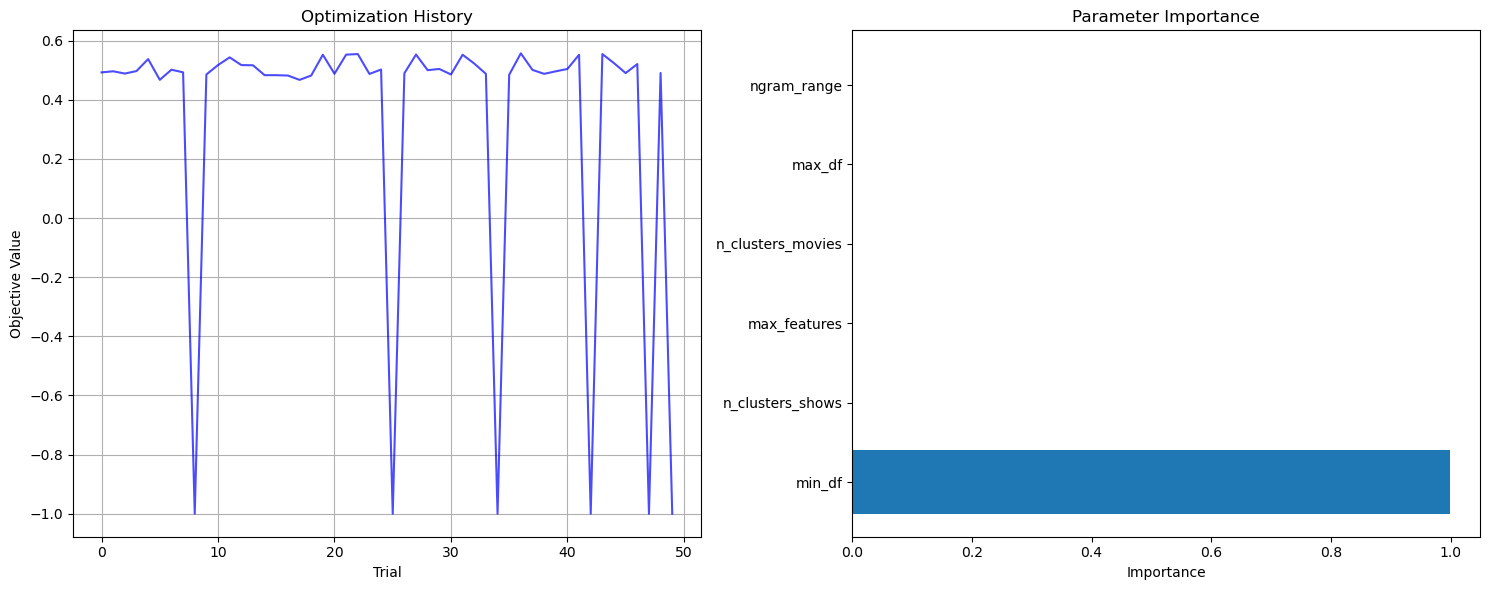

Skapar optimerat rekommendationssystem...
Silhouette Score: 0.2623
System är redo!

Testar med film: 07:19


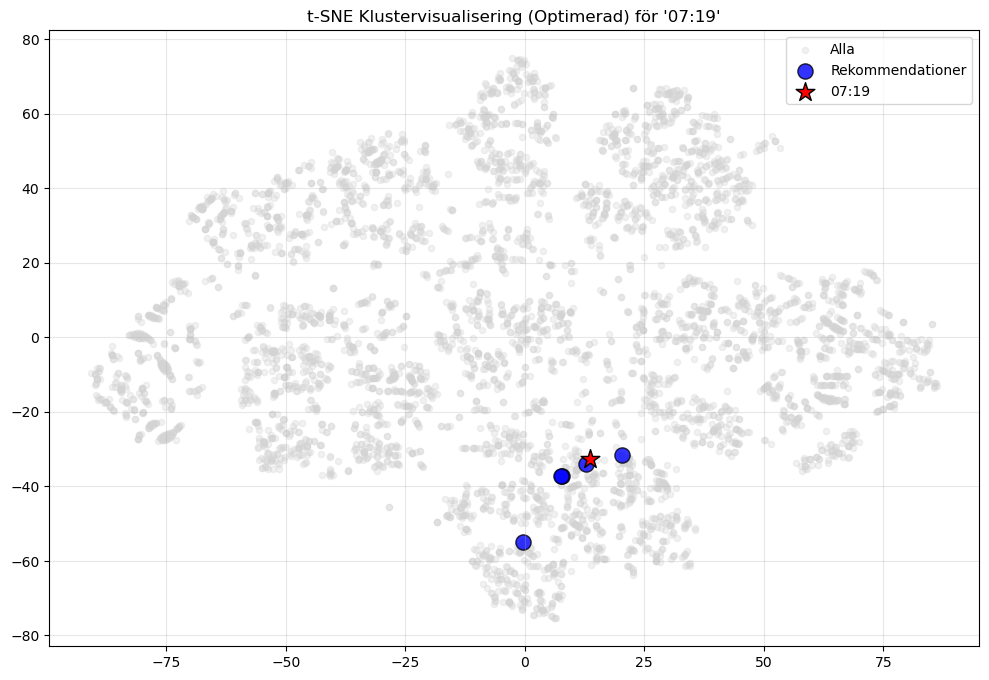


De 5 bästa rekommendationerna för '07:19':
1. Semana Santa
2. Mr. Pig
3. Chatô: The King of Brazil
4. Los Herederos
5. Acapulco La vida va

Testar med serie: 3%


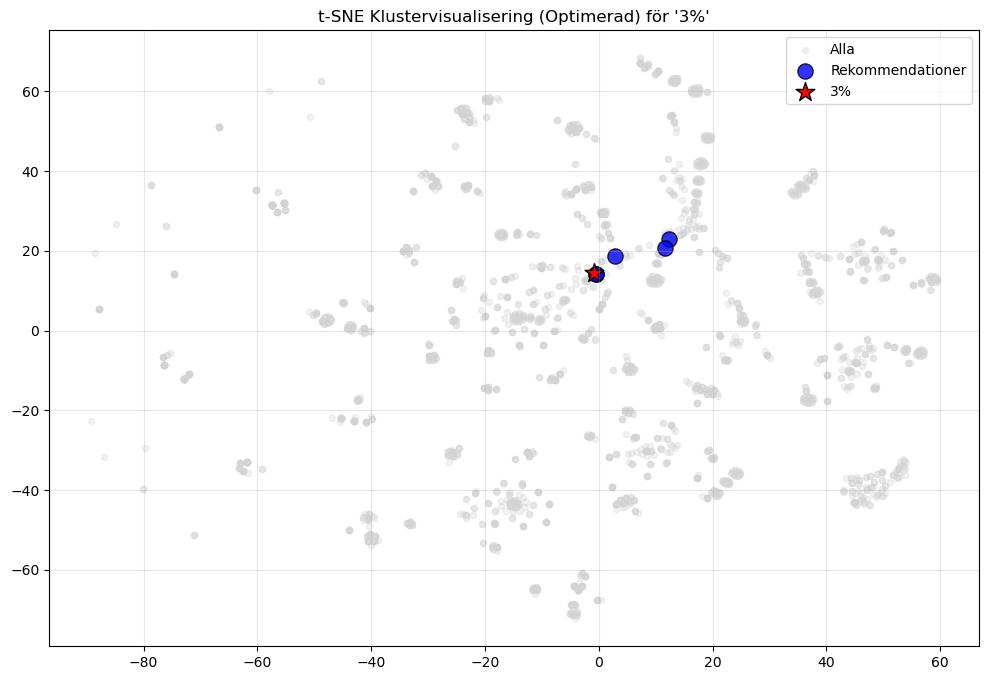


De 5 bästa rekommendationerna för '3%':
1. Queen of the South
2. F is for Family
3. El señor de los Cielos
4. Patriot Act with Hasan Minhaj
5. Cable Girls


In [40]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Ladda data
df = pd.read_csv("Netflix Dataset.csv")

# Kolla datatyper
print(df.dtypes)
print(df.head())

# Filmer: Duration innehåller "min"
movies = df[df['Duration'].str.contains("min", na=False)].copy()
shows = df[df['Duration'].str.contains("Season", na=False)].copy()

# Extrahera minuter och säsonger
movies['Minutes'] = movies['Duration'].str.extract(r'(\d+)').astype(float)
shows['Seasons'] = shows['Duration'].str.extract(r'(\d+)').astype(float)

# Rensa Duration-text
movies['Duration'] = movies['Duration'].str.replace(r'\d+', '', regex=True).str.strip()
shows['Duration'] = shows['Duration'].str.replace(r'\d+', '', regex=True).str.strip()

# Fyll missing description
movies['Description'] = movies['Description'].fillna("")
shows['Description'] = shows['Description'].fillna("")

# Extrahera år
movies['Release_Year'] = pd.to_datetime(movies['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)
shows['Release_Year'] = pd.to_datetime(shows['Release_Date'], errors='coerce').dt.year.fillna(0).astype(int)

# Kontrollera resultat
print(f"Antal filmer: {movies.shape[0]}")
print(movies[['Title', 'Duration', 'Minutes']].head())

print(f"Antal serier: {shows.shape[0]}")
print(shows[['Title', 'Duration', 'Seasons']].head())

# Splitta 'Type' till listor (anta att detta är genrer)
movies['Genres'] = movies['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])
shows['Genres'] = shows['Type'].fillna("Unknown").apply(lambda x: [g.strip() for g in x.split(",")])

# Multi-hot encoding av genrer
mlb = MultiLabelBinarizer()
genres_movies = mlb.fit_transform(movies['Genres'])
genres_shows = mlb.transform(shows['Genres'])

# Vanliga kategoriska features
cat_cols = ['Category', 'Country', 'Rating']
encoder = OneHotEncoder(handle_unknown='ignore')

cat_movies = encoder.fit_transform(movies[cat_cols].fillna('Unknown'))
cat_shows = encoder.transform(shows[cat_cols].fillna('Unknown'))


class OptimizedRecommendationSystem:
    def __init__(self):
        self.tfidf_vectorizer = None
        self.scaler_movies = StandardScaler()
        self.scaler_shows = StandardScaler()
        self.kmeans_movies = None
        self.kmeans_shows = None
        self.X_movies = None
        self.X_shows = None
        self.title_to_idx_movies = None
        self.title_to_idx_shows = None
        self.best_params = None
        
    def build_features(self, movies_df, shows_df, tfidf_params):
        """Bygg features med optimerade parametrar"""
        # TF-IDF med optimerade parametrar
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=tfidf_params['max_features'],
            ngram_range=(1, tfidf_params['ngram_range']),
            min_df=tfidf_params['min_df'],
            max_df=tfidf_params['max_df'],
            stop_words='english'
        )
        
        tfidf_movies = self.tfidf_vectorizer.fit_transform(movies_df['Description'])
        tfidf_shows = self.tfidf_vectorizer.transform(shows_df['Description'])
        
        # Numeriska features
        num_movies = self.scaler_movies.fit_transform(movies_df[['Minutes', 'Release_Year']].fillna(0))
        num_shows = self.scaler_shows.fit_transform(shows_df[['Seasons', 'Release_Year']].fillna(0))
        
        # Kombinera alla features
        self.X_movies = hstack([tfidf_movies, cat_movies, genres_movies, num_movies])
        self.X_shows = hstack([tfidf_shows, cat_shows, genres_shows, num_shows])
        
        self.X_movies = csr_matrix(self.X_movies)
        self.X_shows = csr_matrix(self.X_shows)
        
        return self.X_movies, self.X_shows
    
    def cluster_content(self, cluster_params):
        """Utför klustring med optimerade parametrar"""
        self.kmeans_movies = KMeans(
            n_clusters=cluster_params['n_clusters_movies'],
            random_state=42,
            n_init=10
        )
        movies['Cluster'] = self.kmeans_movies.fit_predict(self.X_movies)
        
        self.kmeans_shows = KMeans(
            n_clusters=cluster_params['n_clusters_shows'],
            random_state=42,
            n_init=10
        )
        shows['Cluster'] = self.kmeans_shows.fit_predict(self.X_shows)
        
        # Skapa title mappings
        self.title_to_idx_movies = pd.Series(movies.index.values, index=movies['Title']).to_dict()
        self.title_to_idx_shows = pd.Series(shows.index.values, index=shows['Title']).to_dict()
        
        # Beräkna silhouette score för utvärdering
        sil_movies = silhouette_score(self.X_movies, movies['Cluster'])
        sil_shows = silhouette_score(self.X_shows, shows['Cluster'])
        
        return (sil_movies + sil_shows) / 2
    
    def get_similar(self, title, top_n=5, is_movie=True, similarity_threshold=0.1):
        """Hitta liknande innehåll med förbättrad algoritm"""
        if is_movie:
            df_ = movies
            X_ = self.X_movies
            title_to_idx = self.title_to_idx_movies
        else:
            df_ = shows
            X_ = self.X_shows
            title_to_idx = self.title_to_idx_shows
            
        if title not in title_to_idx:
            return [], []
        
        idx = title_to_idx[title]
        pos = df_.index.get_loc(idx)
        cluster_id = df_.loc[idx, 'Cluster']
        
        # Kandidater i samma kluster först
        same_cluster = df_[(df_['Cluster'] == cluster_id) & (df_.index != idx)].index.tolist()
        
        if len(same_cluster) >= top_n:
            candidates = same_cluster
        else:
            # Lägg till från andra kluster om nödvändigt
            other_cluster = df_[(df_['Cluster'] != cluster_id) & (df_.index != idx)].index.tolist()
            candidates = same_cluster + other_cluster
        
        if not candidates:
            return [], []
        
        candidate_pos = [df_.index.get_loc(i) for i in candidates]
        sims = cosine_similarity(X_[pos], X_[candidate_pos]).flatten()
        
        # Filtrera på similarity threshold
        valid_idx = np.where(sims >= similarity_threshold)[0]
        if len(valid_idx) == 0:
            valid_idx = np.arange(len(sims))  # Fallback
        
        top_idx = valid_idx[np.argsort(sims[valid_idx])[::-1][:top_n]]
        similar_idx = [candidates[i] for i in top_idx]
        
        return df_.loc[similar_idx, 'Title'].tolist(), similar_idx


def objective(trial):
    """Optuna objective function för hyperparameter optimering"""
    
    # Föreslå hyperparametrar
    tfidf_params = {
        'max_features': trial.suggest_int('max_features', 1000, 10000),
        'ngram_range': trial.suggest_int('ngram_range', 1, 3),
        'min_df': trial.suggest_float('min_df', 0.01, 0.1),
        'max_df': trial.suggest_float('max_df', 0.7, 0.95)
    }
    
    cluster_params = {
        'n_clusters_movies': trial.suggest_int('n_clusters_movies', 3, 15),
        'n_clusters_shows': trial.suggest_int('n_clusters_shows', 3, 10)
    }
    
    try:
        # Skapa och träna systemet
        rec_system = OptimizedRecommendationSystem()
        rec_system.build_features(movies, shows, tfidf_params)
        silhouette_avg = rec_system.cluster_content(cluster_params)
        
        # Testa rekommendationer på några exempel
        test_titles_movies = movies['Title'].head(10).tolist()
        test_titles_shows = shows['Title'].head(5).tolist()
        
        recommendation_quality = 0
        total_tests = 0
        
        # Testa filmrekommendationer
        for title in test_titles_movies:
            similar_titles, _ = rec_system.get_similar(title, top_n=5, is_movie=True)
            if similar_titles:
                recommendation_quality += len(similar_titles) / 5.0
            total_tests += 1
        
        # Testa serierekommendationer
        for title in test_titles_shows:
            similar_titles, _ = rec_system.get_similar(title, top_n=5, is_movie=False)
            if similar_titles:
                recommendation_quality += len(similar_titles) / 5.0
            total_tests += 1
        
        if total_tests > 0:
            recommendation_quality /= total_tests
        
        # Kombinera silhouette score och recommendation quality
        final_score = 0.6 * silhouette_avg + 0.4 * recommendation_quality
        
        return final_score
        
    except Exception as e:
        print(f"Fel i trial: {e}")
        return -1.0


def run_optimization():
    """Kör Optuna optimering"""
    print("Startar Optuna optimering...")
    
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    
    print("Optimering klar!")
    print(f"Bästa score: {study.best_value:.4f}")
    print(f"Bästa parametrar: {study.best_params}")
    
    return study.best_params, study


def plot_optimization_history(study):
    """Visualisera optimeringshistoriken"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Optimization history
    trials = study.trials
    values = [trial.value for trial in trials if trial.value is not None]
    
    ax1.plot(values, 'b-', alpha=0.7)
    ax1.set_title('Optimization History')
    ax1.set_xlabel('Trial')
    ax1.set_ylabel('Objective Value')
    ax1.grid(True)
    
    # Parameter importance
    try:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())
        importances = list(importance.values())
        
        ax2.barh(params, importances)
        ax2.set_title('Parameter Importance')
        ax2.set_xlabel('Importance')
    except:
        ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                ha='center', va='center', transform=ax2.transAxes)
    
    plt.tight_layout()
    plt.show()


def create_optimized_system(best_params):
    """Skapa det optimerade systemet med bästa parametrarna"""
    print("Skapar optimerat rekommendationssystem...")
    
    rec_system = OptimizedRecommendationSystem()
    
    tfidf_params = {
        'max_features': best_params['max_features'],
        'ngram_range': best_params['ngram_range'],
        'min_df': best_params['min_df'],
        'max_df': best_params['max_df']
    }
    
    cluster_params = {
        'n_clusters_movies': best_params['n_clusters_movies'],
        'n_clusters_shows': best_params['n_clusters_shows']
    }
    
    rec_system.build_features(movies, shows, tfidf_params)
    silhouette_score = rec_system.cluster_content(cluster_params)
    
    print(f"Silhouette Score: {silhouette_score:.4f}")
    print("System är redo!")
    
    return rec_system


def plot_tsne_optimized(rec_system, title, top_n=5, is_movie=True):
    """t-SNE visualisering med det optimerade systemet"""
    if is_movie:
        df_ = movies
        X_ = rec_system.X_movies
        title_to_idx = rec_system.title_to_idx_movies
    else:
        df_ = shows
        X_ = rec_system.X_shows
        title_to_idx = rec_system.title_to_idx_shows
    
    titles, sim_idx = rec_system.get_similar(title, top_n, is_movie)
    if len(titles) == 0:
        print(f"Titel '{title}' hittades inte.")
        return
    
    idx = title_to_idx[title]
    pos = df_.index.get_loc(idx)
    sim_positions = [df_.index.get_loc(i) for i in sim_idx]
    
    # PCA → 50D först för att minska dimensionalitet
    n_components = min(50, X_.shape[1], X_.shape[0]-1)
    X_50d = PCA(n_components=n_components, random_state=42).fit_transform(X_.toarray())
    
    # t-SNE → 2D
    perplexity = min(30, len(df_)-1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca')
    X_2d = tsne.fit_transform(X_50d)
    
    plt.figure(figsize=(12, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', alpha=0.3, label='Alla', s=20)
    plt.scatter(X_2d[sim_positions, 0], X_2d[sim_positions, 1], 
               c='blue', s=120, label='Rekommendationer', edgecolor='black', alpha=0.8)
    plt.scatter(X_2d[pos, 0], X_2d[pos, 1], 
               c='red', s=200, label=title, marker='*', edgecolor='black')
    
    plt.title(f"t-SNE Klustervisualisering (Optimerad) för '{title}'")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\nDe {len(titles)} bästa rekommendationerna för '{title}':")
    for i, t in enumerate(titles, 1):
        print(f"{i}. {t}")


# Huvudkörning
if __name__ == "__main__":
    # Kör optimering
    best_params, study = run_optimization()
    
    # Visualisera optimering
    plot_optimization_history(study)
    
    # Skapa optimerat system
    optimized_system = create_optimized_system(best_params)
    
    # Testa systemet
    if len(movies) > 0:
        test_movie = movies['Title'].iloc[0]
        print(f"\nTestar med film: {test_movie}")
        plot_tsne_optimized(optimized_system, test_movie, top_n=5, is_movie=True)
    
    if len(shows) > 0:
        test_show = shows['Title'].iloc[0]
        print(f"\nTestar med serie: {test_show}")
        plot_tsne_optimized(optimized_system, test_show, top_n=5, is_movie=False)